## Multicellular Factor Analysis for spatial data

---

**NOTE**
This is an advanced user notebook. Familiarity with MOFA-based multicellular factor analysis and spatial single-cell analysis is assumed.

---

Patient maps built from single-cell and spatial data can integrate multiple tissue descriptors into a shared latent space. In previous tutorials, we focused mainly on expression-derived multicellular programs. However, spatial data also allows us to describe tissue organization: not only which cell types are present and transcriptionally active, but also how they are arranged relative to each other.

In this tutorial, we extend the MINA workflow by adding a spatial view based on `Squidpy`'s ** neighborhood enrichment**. For each tissue sample, we quantify whether pairs of cell types are enriched or depleted as spatial neighbors, generating a sample-by-cell-type-pair matrix. This matrix is then incorporated as an additional view in the patient map.

This allows the model to jointly capture:

* multicellular gene expression programs
* spatial organization programs
* tissue differences that may not be visible from expression data alone

---

### Application to Xenium IBD data

We apply this workflow to Xenium spatial transcriptomics data from the intestinal IBD atlas reported in [Pokatayev et al., Nature 2026](https://www.nature.com/articles/s41586-025-09907-x), including Crohn’s disease, ulcerative colitis, and non-IBD intestinal tissue samples.

By integrating neighborhood enrichment as an additional view, we ask whether disease-associated tissue differences are reflected not only in transcriptional programs, but also in the local organization of epithelial, immune, stromal, and fibroblast populations.

This tutorial illustrates how MINA can incorporate spatial tissue descriptors into patient maps, providing a flexible framework to compare molecular and structural sources of variation across samples. However this tutorial should be useful for users trying to extend their models to multiple other tissue features.

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scanpy as sc
import mudata as md
import mofaflex as mf
import os
import mina

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



... storing 'biosample_id' as categorical


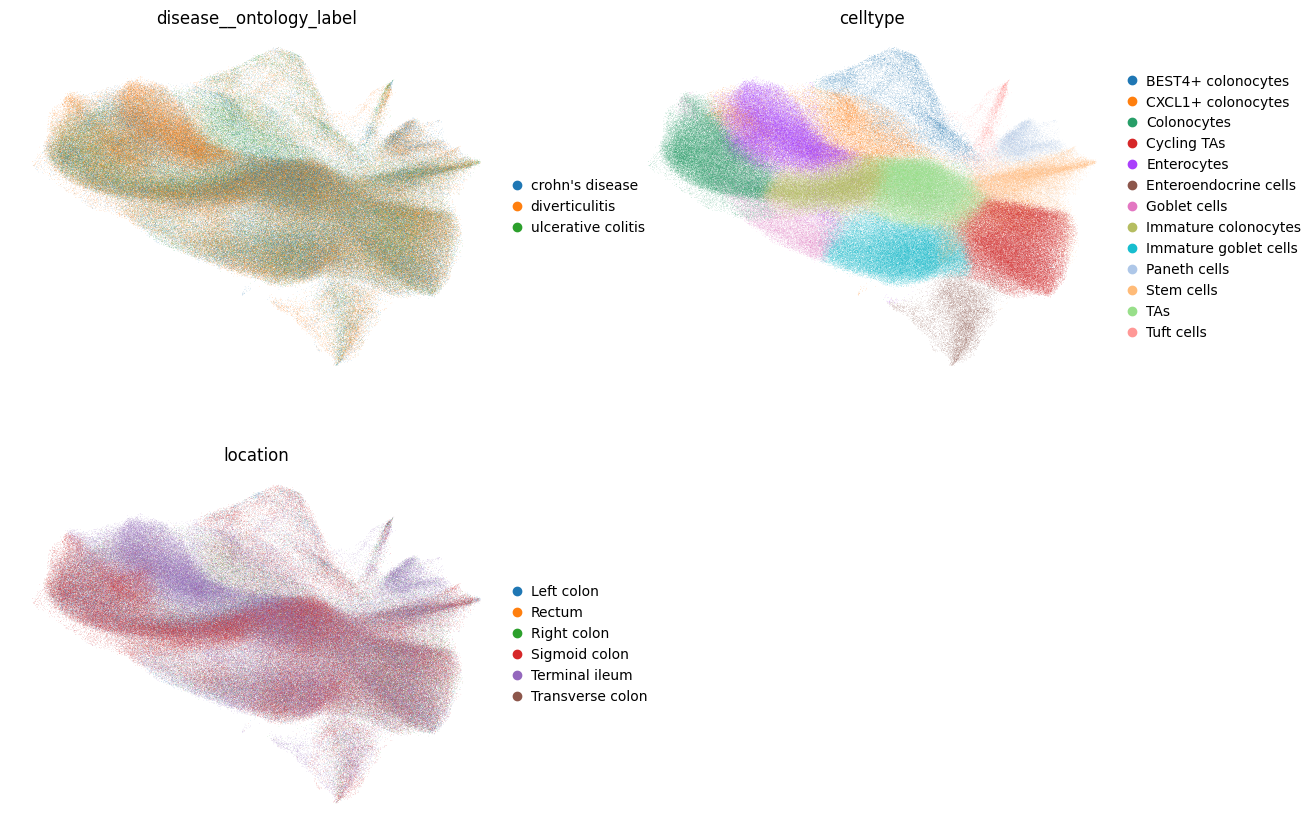

In [2]:
adata = ad.read_h5ad("./data/scp_xenium_human_epi.h5ad")
adata.obs["biosample_id"] = adata.obs["biosample_id"].astype("str")
sc.pl.umap(adata, color=["disease__ontology_label", 'celltype', 'location'], frameon=False, ncols=2)

### Processing the AnnData and preparing it for model fitting

Xenium data can be processed identically as single-cell data, thus we can easily used the same functions described in previous tutorials.

In [3]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype", layer="counts")

# Manipulations on pdata
pdata.obs = pdata.obs.set_index("biosample_id", drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts


# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)

# Do filters
mina.up.filter_anndata_by_ncells(anndata_dict, min_cells=20)
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 5)
mina.up.utils.append_view_to_var(anndata_dict)

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['107990', '108731', '117237', '144732', '146685']

    Inferred to be: categorical



Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


### Fit the multicellular factor model

We first we will fit a model on expression data only to find if we are able to distinguish differences between IBD and non-IBD samples from expression alone. The model is fitted identically as in previous tutorials

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalit

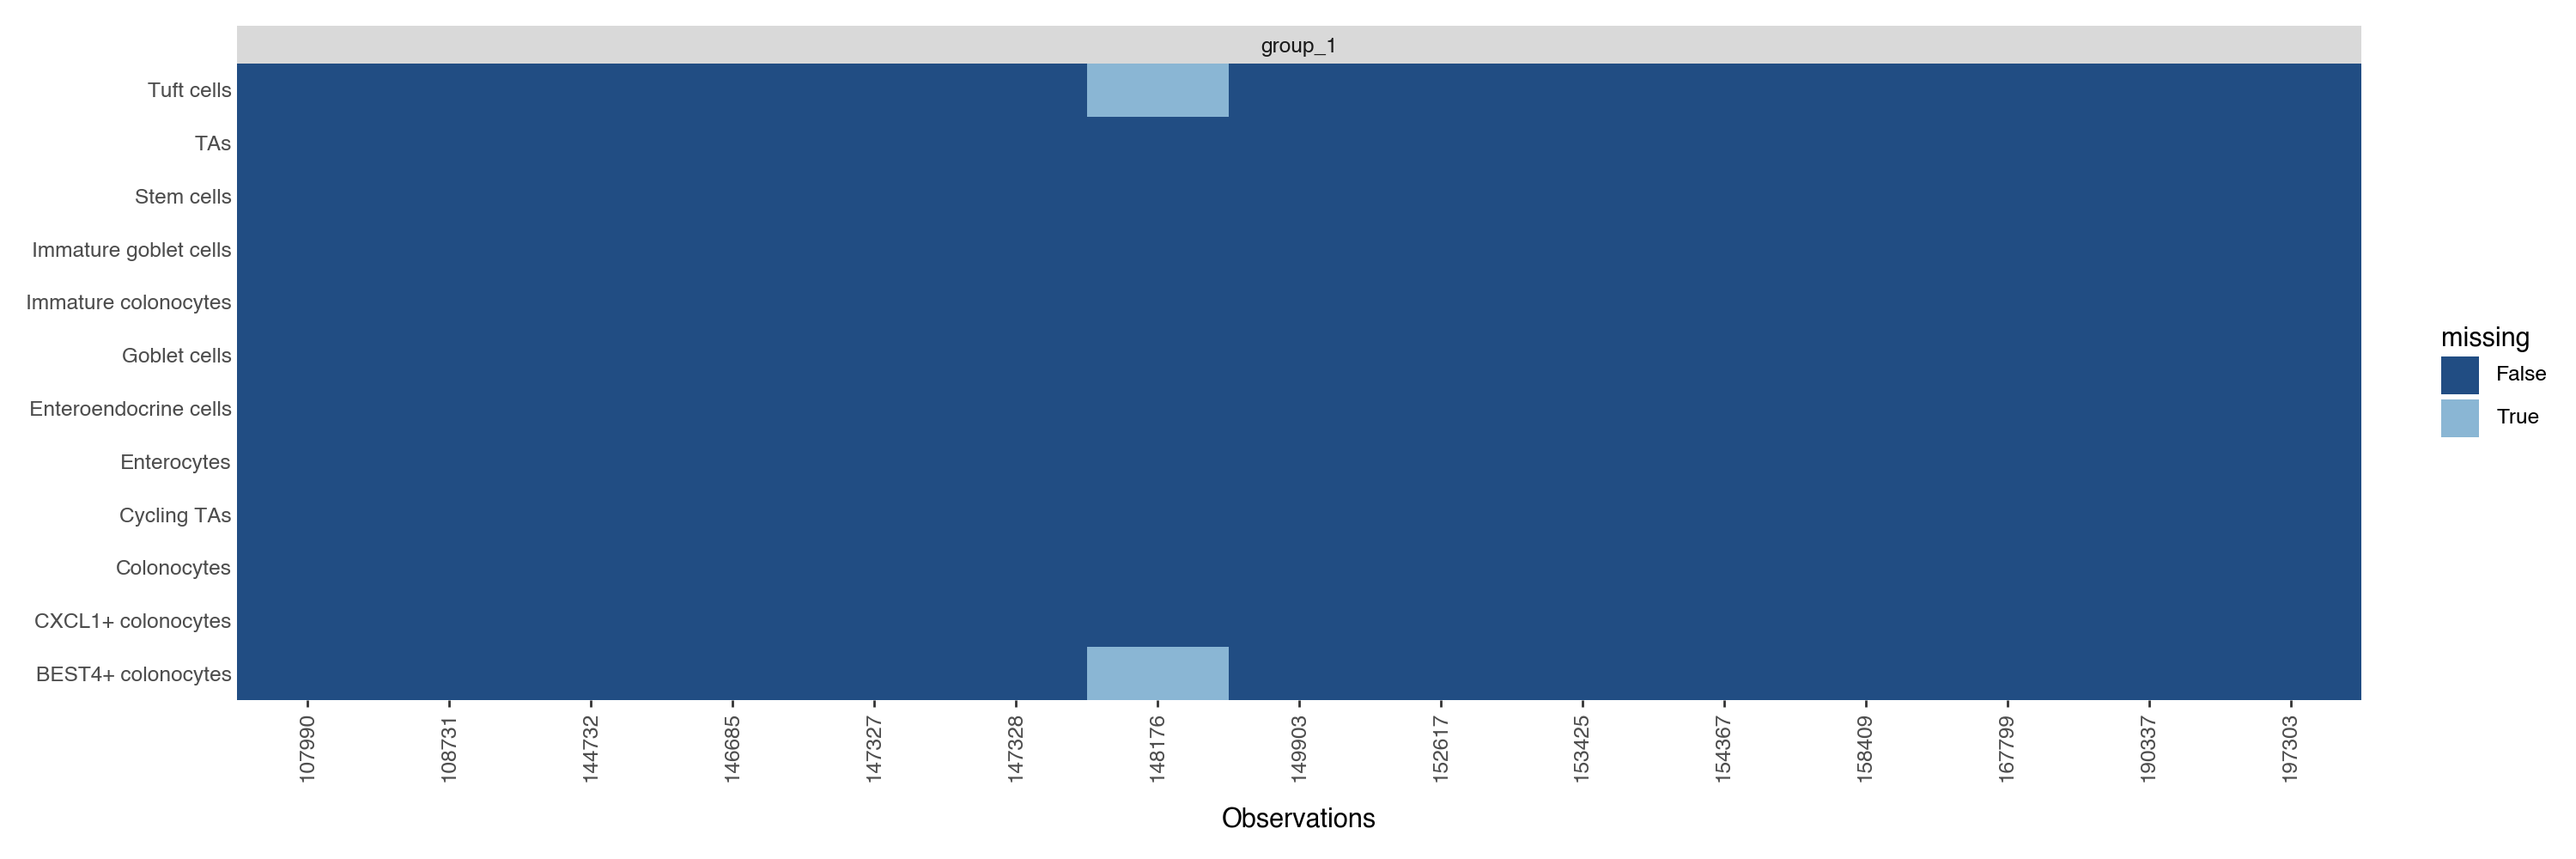

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalit

In [4]:
mdata = md.MuData(anndata_dict)
# Fitting model
model = mf.terms.MofaFlex(n_factors=3, weight_prior="SpikeSlab", init_factors="pca")
model.fit(mdata, seed=42, save_path=False, lr=0.01, early_stopper_patience=1000, likelihoods="Normal")

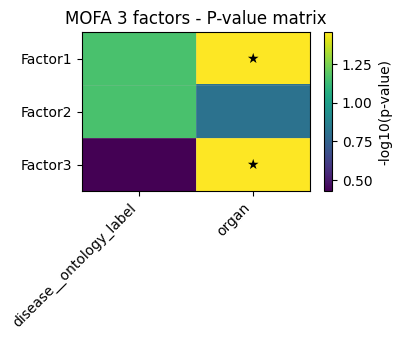

In [5]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mina.down.get_pval_matrix(amodel,["disease__ontology_label", "organ"])
mina.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 3 factors - P-value matrix",star_threshold=0.05)
plt.show()

### Adding spatial information

In this setup, gene expression data does not recover differences between diseases, but what if we could add a new covariate that incorporates other relevant features, such as spatial structure. `squidpy` offers multiple spatial metrics, but for simplicity we have wrapped their spatial enrichment metrics, so that for a given multi-sample dataset one can generate a view with spatial information.

Given the use of lists of anndatas, adding any other tissue descriptor is intuitive and easy to do.

In [6]:
spatial_interaction_adata = mina.up.get_nhood_enrichment_feats(
    adata,
    sample_key="biosample_id",
    cluster_key="celltype",
    diagonal = True, # To co
    n_perms=1000,
)

# Don't forget to add the view name to the variables for compatibility
mina.up.utils.append_view_to_var({"Spatial":spatial_interaction_adata})

anndata_dict["Spatial"] = spatial_interaction_adata

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:03<00:00, 253.87/s]


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:03<00:00, 261.02/s]


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


...

100%|██████████| 1000/1000 [00:03<00:00, 294.81/s]


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:02<00:00, 379.47/s]
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/squidpy/gr/_nhood.py:217: RuntimeWarning: invalid value encountered in divide


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:04<00:00, 235.42/s]


### Fit the multicellular factor model

Now we just need to re-run the model with this additional view. Nothing changes

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalit

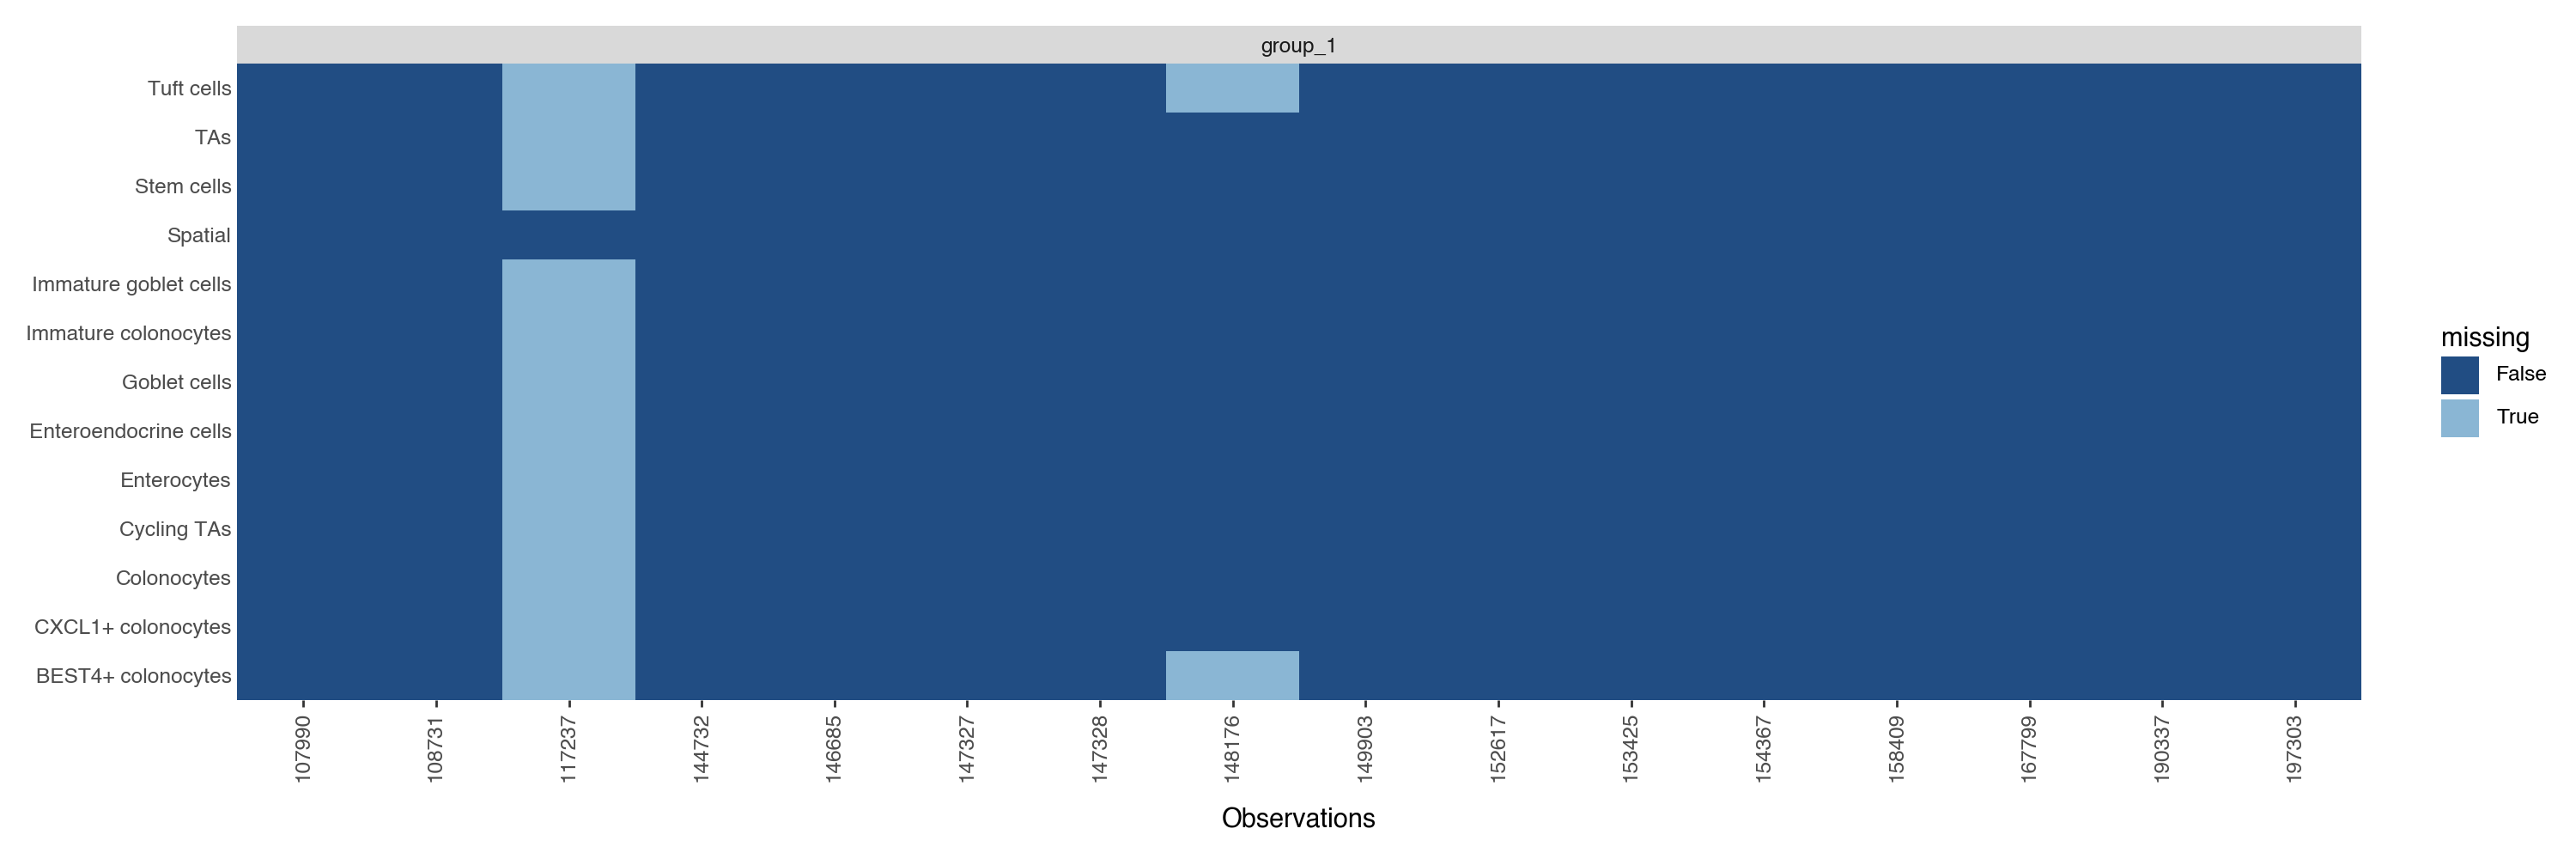

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalit

In [7]:
mdata = md.MuData(anndata_dict)
# Fitting model
model_spatial = mf.terms.MofaFlex(n_factors=3, weight_prior="SpikeSlab", init_factors="pca")
model_spatial.fit(mdata, seed=42, save_path=False, lr=0.01, early_stopper_patience=1000, likelihoods="Normal")

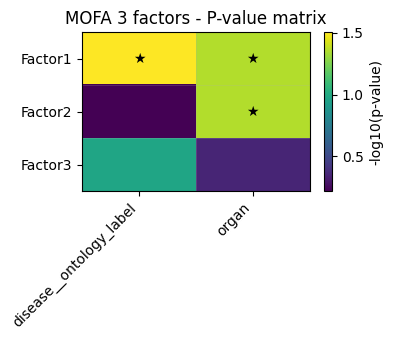

In [8]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model_spatial,
)

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mina.down.get_pval_matrix(amodel,["disease__ontology_label", "organ"])
mina.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 3 factors - P-value matrix",star_threshold=0.05)
plt.show()

In this model we identify a factor associated with the distinct diseases, thus adding the spatial information impacted positively the description of patients

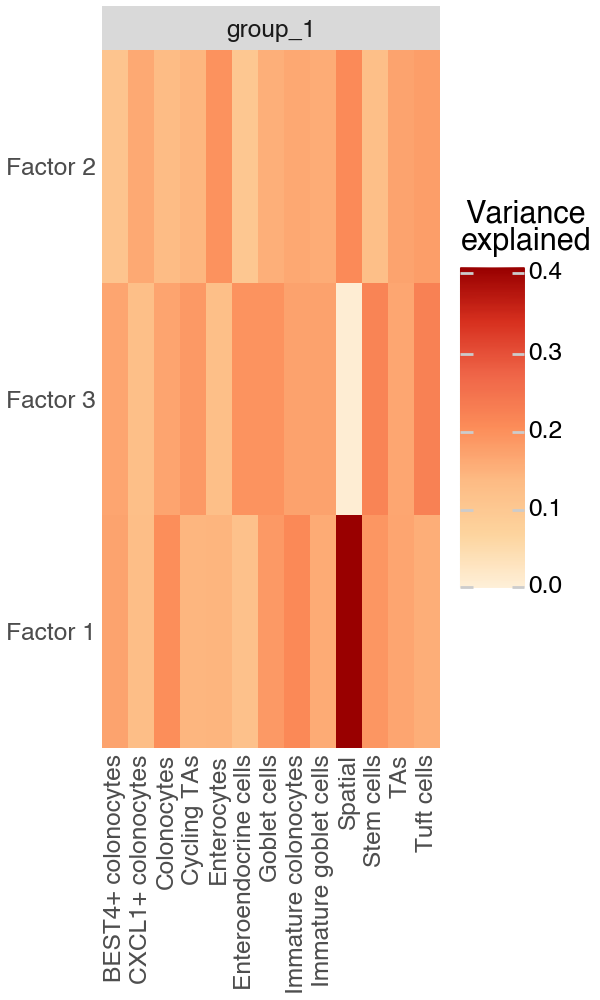

In [9]:
mf.pl.variance_explained(model_spatial)

A clearer quantification is looking at the explained variance. We observe that Factor 1, explains a large portion of variance of the spatial view. At the same time, this result supports the evident relationship between spatial organization and multicellular gene expression coordination.

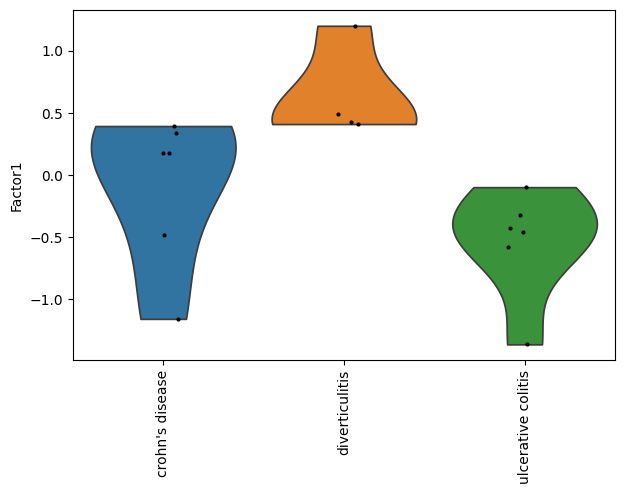

In [10]:
sc.pl.violin(amodel, 
             "Factor1", 
             groupby="disease__ontology_label", rotation=90,size = 3)

In [11]:
feature_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
feature_loadings.index = amodel.var.index.to_list()

# Make a dictionary of gene expression data
feature_loadings = mina.down.split_by_view(feature_loadings)

In [12]:
# Take the top loadings for the spatial view
spatial_loadings = {"Spatial":feature_loadings["Spatial"]}
feature_loadings = {k:v for k,v in feature_loadings.items() if k != "Spatial"}

In [13]:
# Pick top 10 most negative and positive loadings for the spatial view
F1_loadings = spatial_loadings["Spatial"].loc["Factor1",:]
F1_loadings = F1_loadings.sort_values()
top_pos = F1_loadings.tail(10)
top_neg = F1_loadings.head(10)
top_loadings = pd.concat([top_pos, top_neg])

/Users/flores/Dropbox/EBI/Research/MINA/src/mina/pl/pl.py:755: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


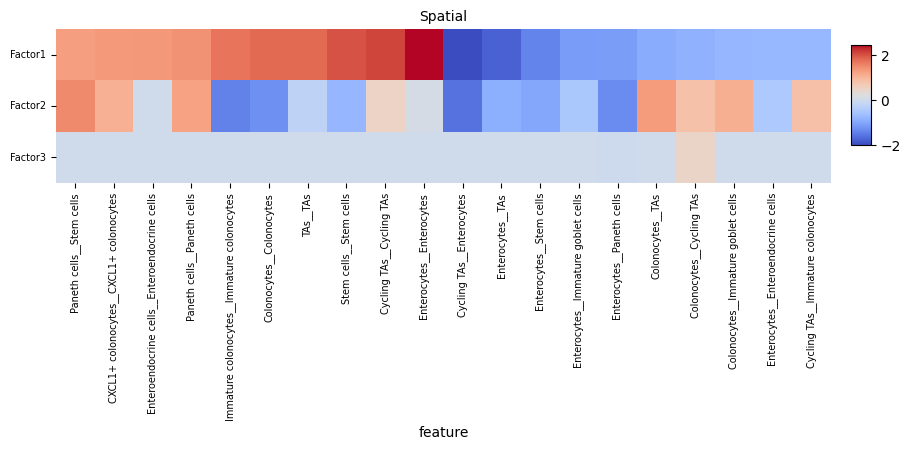

In [14]:
mina.pl.plot_features_per_view(df_dict=spatial_loadings, features=top_loadings.index.tolist(), figsize=(10, 2))

In [46]:
# Get the samples with the highest and lowest factor values for factor 1, data in X
factor_values = amodel.X[:, 0]  # Factor 1 values
top_samples = np.argsort(factor_values)[-2:]  # Top 1 samples
bottom_samples = np.argsort(factor_values)[:2]  # Bottom 1 samples
# put them in a list
top_bottom_samples = np.concatenate([top_samples, bottom_samples])
top_bottom_samples = amodel.obs.iloc[top_bottom_samples]
top_bottom_samples = top_bottom_samples["biosample_id"].tolist()

/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/Users/flores/Dropbox/EBI/Research/MINA_docs/.venv/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping 

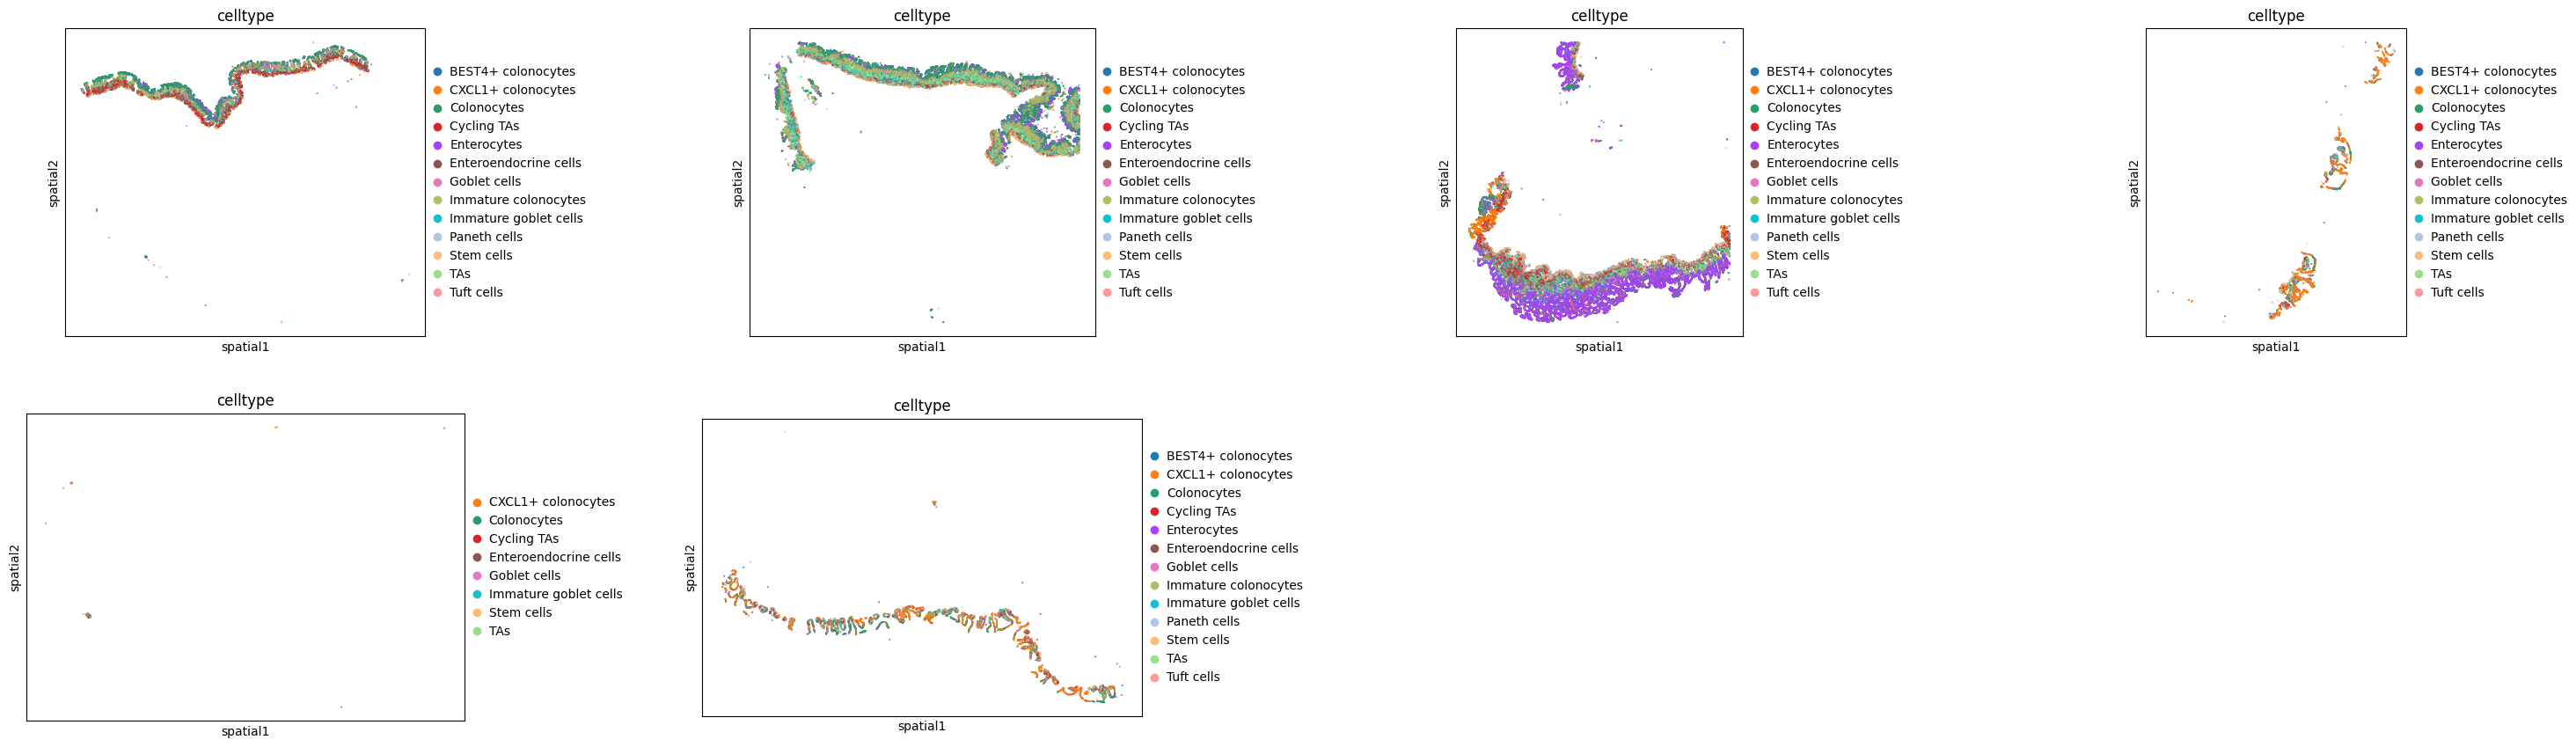

In [47]:
import squidpy as sq

sq.pl.spatial_scatter(
    adata,
    library_key= "biosample_id",
    library_id = top_bottom_samples,
    shape=None,
    color=[
        "celltype",
    ],
    wspace=0.4,
)

In [28]:
MINs = mina.down.get_multicell_net(
    test_model = amodel,
    sel_factor = "Factor1",
    random_effect = None,
    standardize = True,
    drop_na = True,
    verbose = True,
    views=[k for k in feature_loadings.keys()],
    percentile=0.6
)

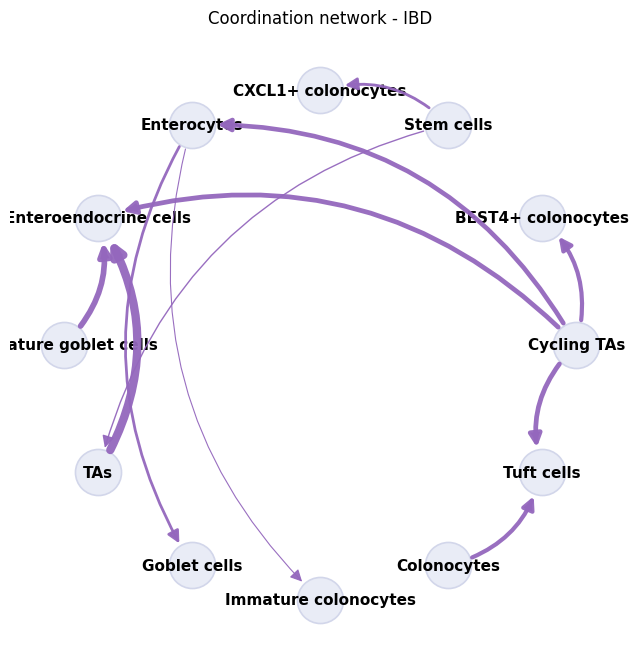

In [31]:
graph_viz = mina.pl.plot_mcell_network(
    df = MINs["negative"],
    weight_col="cor_estimate",
    abs_cutoff=0.8,
    keep_negative=False,
    title="Coordination network - IBD",
    show_edge_labels = False,
    save_path=None,
    reciprocal_curvature=0.3,
    default_curvature=0.4)

Running ULM for view: BEST4+ colonocytes
Running ULM for view: CXCL1+ colonocytes
Running ULM for view: Colonocytes
Running ULM for view: Cycling TAs
Running ULM for view: Enterocytes
Running ULM for view: Enteroendocrine cells
Running ULM for view: Goblet cells
Running ULM for view: Immature colonocytes
Running ULM for view: Immature goblet cells
Running ULM for view: Stem cells
Running ULM for view: TAs
Running ULM for view: Tuft cells


/Users/flores/Dropbox/EBI/Research/MINA/src/mina/pl/pl.py:474: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


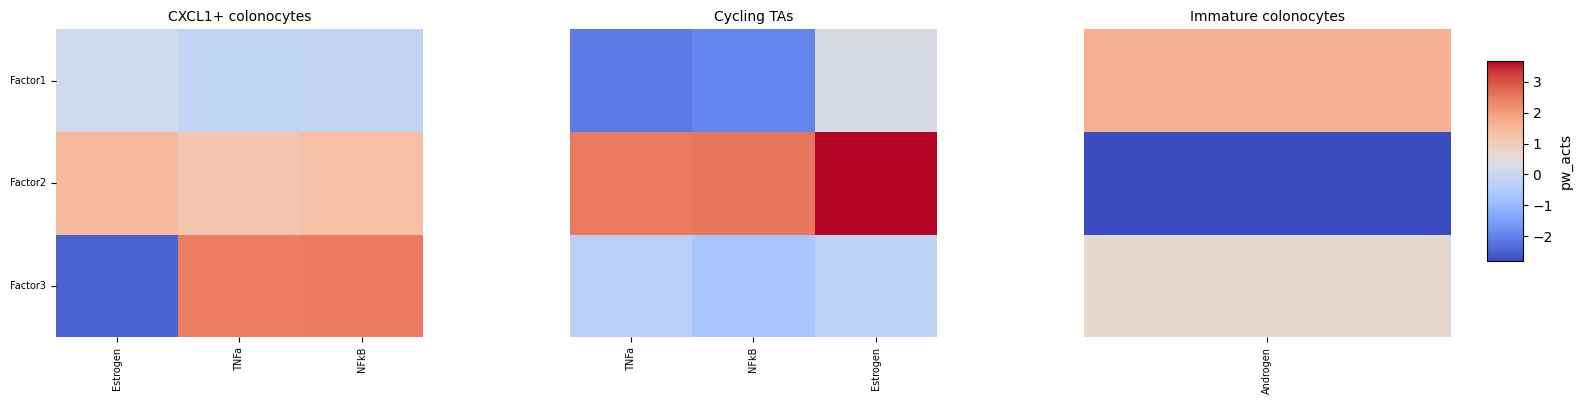

In [33]:
# Now you can run decoupler for each matrix of gene loadings
progeny = dc.op.progeny(organism="human", top=1000)
mcp_pws = mina.down.run_ulm_per_view(view_dict=feature_loadings, net=progeny)
mina.pl.plot_mcell_funcomics(mcp_pws, 
                     p_threshold=0.05,
                     top_n=15,
                     use_var=True,
                     figsize=(18, 4))